### Investigate why periodic acts weird

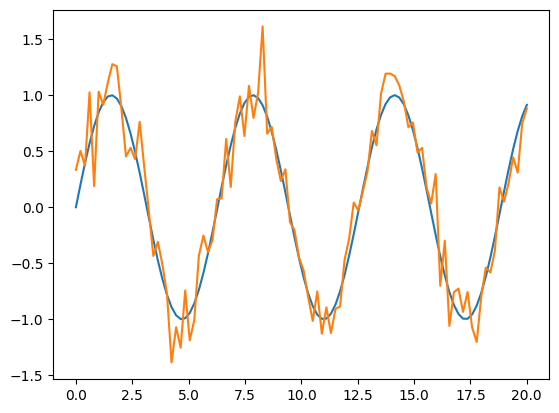

In [7]:
import torch
import gpytorch
import matplotlib.pyplot as plt

# Fake data
x = torch.linspace(0,20,100)
f = torch.sin(x)
y = torch.normal(mean = f ,std =.2)

plt.plot(x,f)
plt.plot(x,y)

In [8]:
from gpytorch.models import ExactGP
from gpytorch.distributions import MultivariateNormal

class GP(ExactGP):
    def __init__(self, train_inputs, train_targets, likelihood, kernel, mean):
        super().__init__(train_inputs, train_targets, likelihood)
        self.train_x = train_inputs
        self.train_y = train_targets
        self.mean = mean
        self.kernel = kernel
        # self.likelihood = likelihood
    def forward(self, x: torch.Tensor) -> MultivariateNormal:
        mean_x = self.mean(x)
        covar_x = self.kernel(x)
        return MultivariateNormal(mean_x, covar_x)
    
    def fit(self, training_iter = 50, verbose: bool = False):
        # Find optimal model hyperparameters
        self.train()
        self.likelihood.train()

        # Use the adam optimizer
        optimizer = torch.optim.Adam(self.parameters(), lr=.1)  # Includes GaussianLikelihood parameters

        # "Loss" for GPs - the marginal log likelihood
        mll = gpytorch.mlls.LeaveOneOutPseudoLikelihood(self.likelihood, self)

        for i in range(training_iter):
            # Zero gradients from previous iteration
            optimizer.zero_grad()
            # Output from model
            output = self(self.train_x)
            # Calc loss and backprop gradients
            loss = -mll(output, self.train_y)
            if verbose:
                print('Iter %d/%d - Loss: %.3f' % (i + 1, training_iter, loss.item()))
            loss.backward()
            optimizer.step()
    
    def predict(self, x, latent = False):
        self.eval()
        self.likelihood.eval()
        with torch.no_grad():
            if latent:
                return self(x)
            else:
                return self.likelihood(self(x))

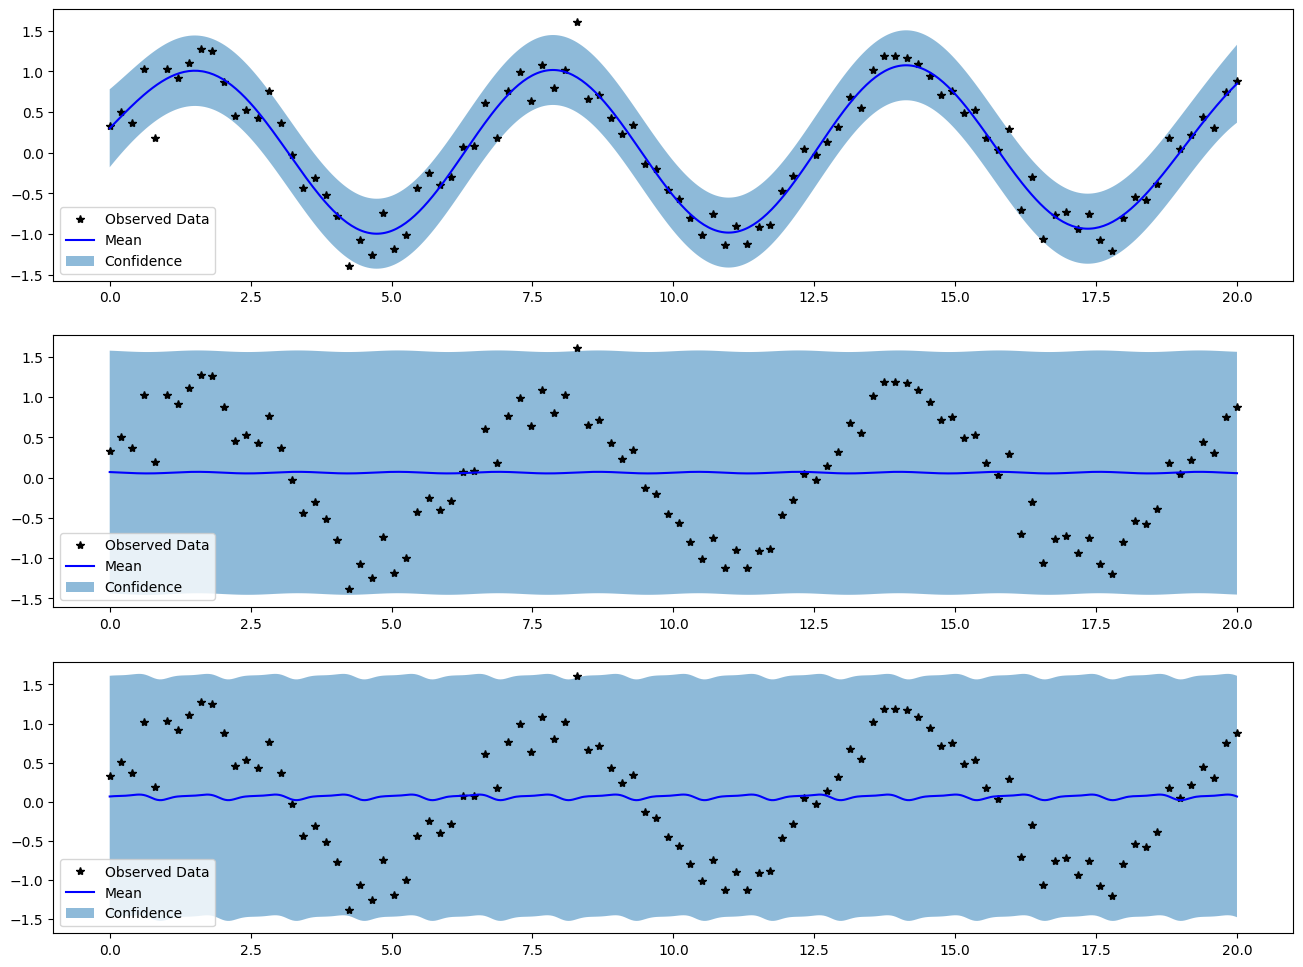

In [9]:
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.kernels import *
from gpytorch.means import ConstantMean

rbf_model = GP(x, y, GaussianLikelihood(), ScaleKernel(RBFKernel()), ConstantMean())
cosine_model = GP(x,y, GaussianLikelihood(), ScaleKernel(CosineKernel()), ConstantMean())
periodic_model = GP(x,y,GaussianLikelihood(), ScaleKernel(PeriodicKernel()), ConstantMean())
rbf_model.fit()
cosine_model.fit()
periodic_model.fit()
models = [rbf_model, cosine_model, periodic_model]

f, ax = plt.subplots(3, 1, figsize=(16, 12))
pred_x = torch.linspace(0,20,500)
for i in range(3):
    observed_pred = models[i].predict(pred_x)
    # Get upper and lower confidence bounds
    lower, upper = observed_pred.confidence_region()
    # Plot training data as black stars
    ax[i].plot(x.numpy(), y.numpy(), 'k*')
    # Plot predictive means as blue line
    ax[i].plot(pred_x.numpy(), observed_pred.mean.numpy(), 'b')
    # Shade between the lower and upper confidence bounds
    ax[i].fill_between(pred_x.numpy(), lower.numpy(), upper.numpy(), alpha=0.5)
    # ax[i].set_ylim([-3, 3])
    ax[i].legend(['Observed Data', 'Mean', 'Confidence'])

tensor([[3.3216]], grad_fn=<SoftplusBackward0>)
tensor(0.2400, grad_fn=<SoftplusBackward0>)


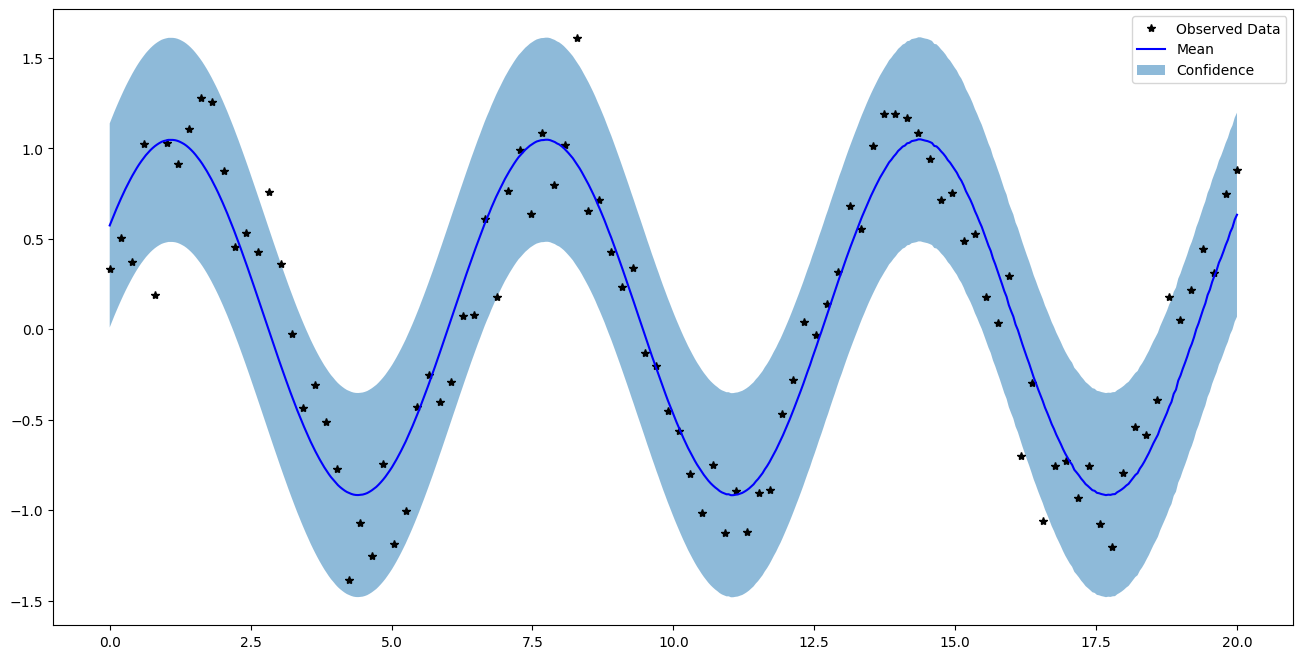

In [10]:
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.kernels import *
from gpytorch.means import ConstantMean, ZeroMean
from gpytorch.priors import NormalPrior
from gpytorch.constraints import Interval

kernel = ScaleKernel(
            # CosineKernel(period_length_constraint=Interval(torch.pi - .05, torch.pi+.05)),
            CosineKernel(
                        # period_length_constraint=Interval(9.5,10), 
                        period_length_prior=NormalPrior(torch.tensor(6.3237/2),torch.tensor(0.0299))
                         ),
            # outputscale_constraint=Interval(5,10)
            )


cosine_model = GP(x,y, 
                    likelihood = GaussianLikelihood(), 
                    kernel = kernel,
                    mean = ConstantMean()
                )

cosine_model.fit()

models = [cosine_model]

print(models[0].kernel.base_kernel.period_length)
print(models[0].kernel.outputscale)
models[0].kernel.outputscale = 20

f, ax = plt.subplots(1, 1, figsize=(16,8))
pred_x = torch.linspace(0,20,500)
for i in range(1):
    observed_pred = models[i].predict(pred_x)
    # Get upper and lower confidence bounds
    lower, upper = observed_pred.confidence_region()
    # Plot training data as black stars
    ax.plot(x.numpy(), y.numpy(), 'k*')
    # Plot predictive means as blue line
    ax.plot(pred_x.numpy(), observed_pred.mean.numpy(), 'b')
    # Shade between the lower and upper confidence bounds
    ax.fill_between(pred_x.numpy(), lower.numpy(), upper.numpy(), alpha=0.5)
    # ax[i].set_ylim([-3, 3])
    ax.legend(['Observed Data', 'Mean', 'Confidence'])

In [11]:
import numpy as np
import sys

# Try importing mpmath. If not available, try to import it from sympy.
try:
    import mpmath
except ImportError:
    try:
        from sympy import mpmath
    except ImportError:
        raise ImportError("mpmath is required. Please install it via 'pip install mpmath'.")

pi = np.pi

def bgls(t, y, err, plow=0.5, phigh=100, ofac=1):
    """
    Bayesian Generalized Lomb-Scargle periodogram.

    Parameters:
        t (array): time series
        y (array): measured data
        err (array): errors on the data
        plow (float): lower bound of the period range
        phigh (float): upper bound of the period range
        ofac (float): oversampling factor

    Returns:
        periods (array): sampled periods (1/frequency)
        p (array): normalized periodogram power values
    """
    # Set up the frequency grid based on the oversampling factor and period limits
    n_steps = int(ofac * len(t) * (1.0 / plow - 1.0 / phigh))
    f = np.linspace(1.0 / phigh, 1.0 / plow, n_steps)
    omegas = 2.0 * pi * f

    err2 = err**2
    w = 1.0 / err2
    W = np.sum(w)

    bigY = np.sum(w * y)  # Equation (10)

    constants = []
    exponents = []

    for omega in omegas:
        # Compute the phase offset theta
        theta = 0.5 * np.arctan2(np.sum(w * np.sin(2.0 * omega * t)),
                                 np.sum(w * np.cos(2.0 * omega * t)))
        x = omega * t - theta
        cosx = np.cos(x)
        sinx = np.sin(x)
        wcosx = w * cosx
        wsinx = w * sinx

        C = np.sum(wcosx)
        S = np.sum(wsinx)

        YCh = np.sum(y * wcosx)
        YSh = np.sum(y * wsinx)
        CCh = np.sum(wcosx * cosx)
        SSh = np.sum(wsinx * sinx)

        if CCh != 0 and SSh != 0:
            K = (C * C * SSh + S * S * CCh - W * CCh * SSh) / (2.0 * CCh * SSh)
            L = (bigY * CCh * SSh - C * YCh * SSh - S * YSh * CCh) / (CCh * SSh)
            M = (YCh * YCh * SSh + YSh * YSh * CCh) / (2.0 * CCh * SSh)
            constants.append(1.0 / np.sqrt(CCh * SSh * abs(K)))
        elif CCh == 0:
            K = (S * S - W * SSh) / (2.0 * SSh)
            L = (bigY * SSh - S * YSh) / SSh
            M = (YSh * YSh) / (2.0 * SSh)
            constants.append(1.0 / np.sqrt(SSh * abs(K)))
        elif SSh == 0:
            K = (C * C - W * CCh) / (2.0 * CCh)
            L = (bigY * CCh - C * YCh) / CCh
            M = (YCh * YCh) / (2.0 * CCh)
            constants.append(1.0 / np.sqrt(CCh * abs(K)))
        else:
            # This branch should not be reached
            K = L = M = 0
            constants.append(0)

        if K > 0:
            raise RuntimeError("K is positive. This should not happen.")

        exponents.append(M - L * L / (4.0 * K))

    constants = np.array(constants)
    exponents = np.array(exponents)

    # Calculate the logarithm of the probability (power)
    logp = np.log10(constants) + (exponents * np.log10(np.exp(1.0)))

    # Convert log probabilities to linear scale
    p = np.array([10**mpmath.mpf(x) for x in logp], dtype=np.float64)

    # Normalize the periodogram so that its maximum is 1
    p = p / np.max(p)
    p[p < (sys.float_info.min * 10)] = 0
    return 1.0 / f, p

Best period: 1.998 (True period: 2.0)
Mean period: 1.1341764544280628
Variance: 0.8882204541583503


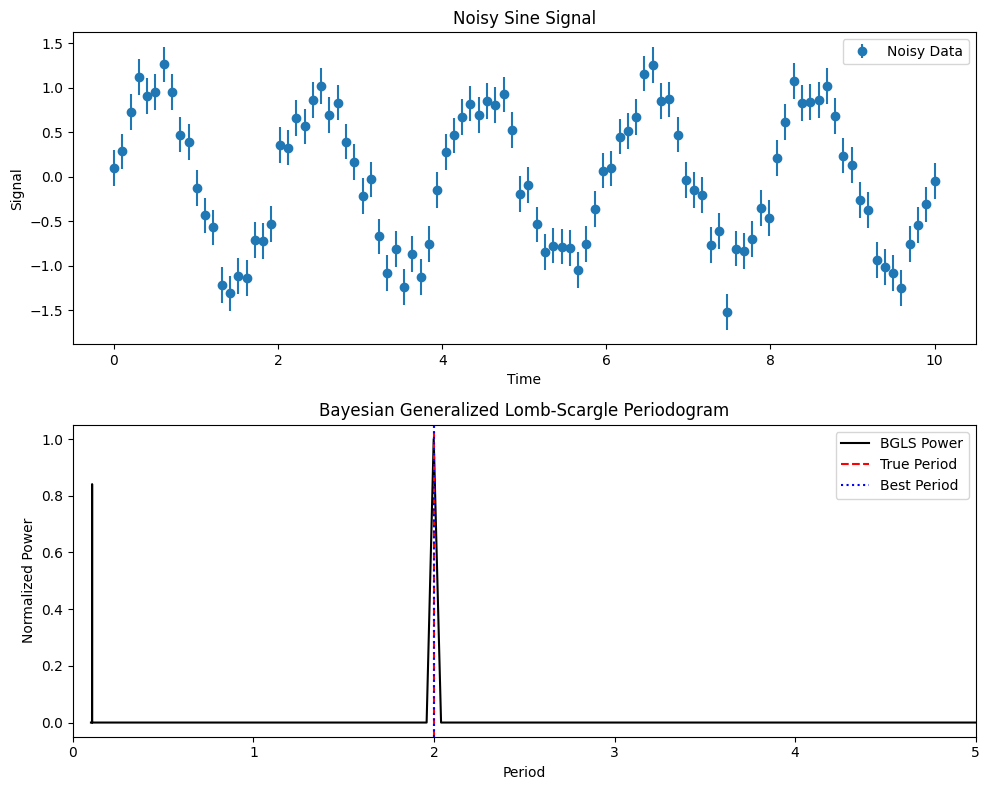

In [12]:
# ---------------------------
# Testing the BGLS implementation
# ---------------------------
import matplotlib.pyplot as plt

# Set a random seed for reproducibility
np.random.seed(42)

# Create a time array and a noisy sine signal
t = np.linspace(0, 10, 100)           # Time from 0 to 10 with 100 points
true_period = 2.0                     # True period of the sine signal
f_true = 1.0 / true_period            # True frequency
noise_level = 0.2                     # Standard deviation of noise

# Generate the noisy sine signal
y = np.sin(2 * np.pi * f_true * t) + np.random.normal(0, noise_level, size=t.shape)
err = np.full_like(t, noise_level)    # Assume constant error for all data points

# Compute the Bayesian Generalized Lomb-Scargle periodogram
# Adjust plow and phigh to cover a range that includes the true period.
periods, power = bgls(t, y, err, plow=0.1, phigh=10, ofac=1)

# Determine the period with the maximum power
best_period = periods[np.argmax(power)]
print(f"Best period: {best_period:.3f} (True period: {true_period})")

# If periods are uniformly spaced, normalize simply:
p_norm = power / np.sum(power)

# Compute weighted mean of the period distribution
mean_period = np.sum(periods * p_norm)

# Compute the weighted variance of the period distribution
variance = np.sum(p_norm * (periods - mean_period)**2)

print(f"Mean period: {mean_period}")
print(f"Variance: {variance}")

# Plot the noisy time series data
fig, axs = plt.subplots(2, 1, figsize=(10, 8))

axs[0].errorbar(t, y, yerr=err, fmt='o', label='Noisy Data')
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Signal')
axs[0].legend()
axs[0].set_title('Noisy Sine Signal')

# Plot the periodogram
axs[1].plot(periods, power, '-k', label='BGLS Power')
axs[1].set_xlabel('Period')
axs[1].set_ylabel('Normalized Power')
axs[1].axvline(true_period, color='r', linestyle='--', label='True Period')
axs[1].axvline(best_period, color='b', linestyle=':', label='Best Period')
axs[1].legend()
axs[1].set_title('Bayesian Generalized Lomb-Scargle Periodogram')
axs[1].set_xlim(0,5)

plt.tight_layout()
plt.show()

Estimated period (weighted mean): 6.3237
Estimated period uncertainty (std): 0.0299


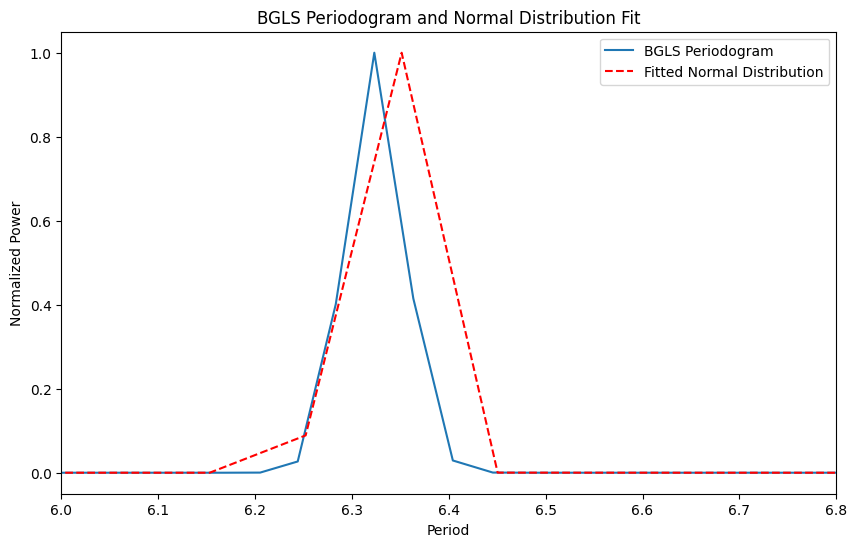

In [13]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Bayesian Generalised Lomb-Scargle periodogram in modern Python.
Based on Mortier et al. (2015).

This script:
  1. Defines the BGLS periodogram function.
  2. Computes a weighted mean and standard deviation of the period.
  3. Tests the periodogram on a noisy sine wave.
  4. Plots the periodogram and overlays a fitted normal distribution.
  
Requirements:
  - numpy
  - matplotlib
  - mpmath
"""

import numpy as np
import matplotlib.pyplot as plt
import mpmath  # if mpmath is not available, let the ImportError occur
import sys

pi = np.pi

def bgls(t, y, err, plow=0.5, phigh=100, ofac=1):
    """
    Compute the Bayesian Generalised Lomb-Scargle periodogram.
    
    Parameters:
      t     : array_like, times of observations
      y     : array_like, observed values
      err   : array_like, errors on observations (assumed to be constant if desired)
      plow  : float, lower bound of period (default 0.5)
      phigh : float, upper bound of period (default 100)
      ofac  : oversampling factor (default 1)
      
    Returns:
      periods : numpy array of periods (1/frequency)
      p       : normalized periodogram power corresponding to each period
    """
    n_steps = int(ofac * len(t) * (1.0/plow - 1.0/phigh))
    # Frequencies range from 1/phigh to 1/plow
    f = np.linspace(1.0/phigh, 1.0/plow, n_steps)
    omegas = 2.0 * pi * f

    err2 = err**2
    w = 1.0 / err2
    W = np.sum(w)
    bigY = np.sum(w * y)
    
    constants = []
    exponents = []
    
    for omega in omegas:
        theta = 0.5 * np.arctan2(np.sum(w * np.sin(2.0 * omega * t)),
                                  np.sum(w * np.cos(2.0 * omega * t)))
        x = omega * t - theta
        cosx = np.cos(x)
        sinx = np.sin(x)
        wcosx = w * cosx
        wsinx = w * sinx
        
        C = np.sum(wcosx)
        S = np.sum(wsinx)
        YCh = np.sum(y * wcosx)
        YSh = np.sum(y * wsinx)
        CCh = np.sum(wcosx * cosx)
        SSh = np.sum(wsinx * sinx)
        
        if CCh != 0 and SSh != 0:
            K = (C * C * SSh + S * S * CCh - W * CCh * SSh) / (2.0 * CCh * SSh)
            L = (bigY * CCh * SSh - C * YCh * SSh - S * YSh * CCh) / (CCh * SSh)
            M = (YCh * YCh * SSh + YSh * YSh * CCh) / (2.0 * CCh * SSh)
            constants.append(1.0 / np.sqrt(CCh * SSh * abs(K)))
        elif CCh == 0:
            K = (S * S - W * SSh) / (2.0 * SSh)
            L = (bigY * SSh - S * YSh) / SSh
            M = (YSh * YSh) / (2.0 * SSh)
            constants.append(1.0 / np.sqrt(SSh * abs(K)))
        elif SSh == 0:
            K = (C * C - W * CCh) / (2.0 * CCh)
            L = (bigY * CCh - C * YCh) / CCh
            M = (YCh * YCh) / (2.0 * CCh)
            constants.append(1.0 / np.sqrt(CCh * abs(K)))
        
        if K > 0:
            raise RuntimeError('K is positive. This should not happen.')
            
        exponents.append(M - L * L / (4.0 * K))
    
    constants = np.array(constants)
    exponents = np.array(exponents)
    
    logp = np.log10(constants) + (exponents * np.log10(np.e))
    p = np.power(10, logp)  # using numpy vectorized power
    
    p = p / np.max(p)  # normalize the periodogram power
    p[p < (np.finfo(float).tiny * 10)] = 0  # set too small values to zero
    p = np.array([float(pp) for pp in p])
    
    periods = 1.0 / f
    return periods, p

def estimate_normal_period(periods, p):
    """
    Estimate the period (as a normal distribution) by computing the weighted mean 
    and standard deviation of the periodogram.
    
    Parameters:
      periods : numpy array of periods
      p       : numpy array of periodogram probabilities
      
    Returns:
      mean : weighted mean period
      std  : weighted standard deviation of the period
    """
    p_norm = p / np.sum(p)  # normalize probabilities for weighting
    mean = np.sum(periods * p_norm)
    variance = np.sum(p_norm * (periods - mean)**2)
    std = np.sqrt(variance)
    return mean, std

def normal_pdf(x, mean, std):
    """
    Normal (Gaussian) probability density function.
    """
    return 1.0/(std * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((x - mean)/std)**2)

# -------------------------------
# Generate a noisy sine wave signal
# -------------------------------
np.random.seed(42)
true_period = 2.0
t = np.linspace(0, 20, 100)  # time array
noise_level = .2
y = np.sin(t) + np.random.normal(0, noise_level, size=t.shape)
err = np.full_like(t, noise_level)  # constant errors

# -------------------------------
# Compute the BGLS periodogram in a period range that includes the true period.
# Adjust plow, phigh, and ofac to zoom in on the expected period.
# -------------------------------
plow = 1.0   # lower bound of period
phigh = 100.0  # upper bound of period
ofac = 10    # oversampling factor for better resolution
periods, p = bgls(t, y, err, plow=plow, phigh=phigh, ofac=ofac)

# -------------------------------
# Estimate the period's normal distribution parameters (mean and standard deviation)
# -------------------------------
period_mean, period_std = estimate_normal_period(periods, p)
print(f"Estimated period (weighted mean): {period_mean:.4f}")
print(f"Estimated period uncertainty (std): {period_std:.4f}")

# -------------------------------
# Plot the periodogram and the fitted normal distribution
# -------------------------------
plt.figure(figsize=(10, 6))
plt.plot(periods, p, label="BGLS Periodogram")

# Create a smooth array of periods for plotting the normal PDF
period_range = np.linspace(np.min(periods), np.max(periods), 1000)
norm_pdf = normal_pdf(period_range, period_mean, period_std)

# Normalize the normal PDF to the same scale as the periodogram
norm_pdf = norm_pdf / np.max(norm_pdf)

plt.plot(period_range, norm_pdf, 'r--', label="Fitted Normal Distribution")
plt.xlabel("Period")
plt.ylabel("Normalized Power")
plt.title("BGLS Periodogram and Normal Distribution Fit")
plt.legend()
plt.xlim(6.00, 6.80)
plt.show()
